In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

from src.helper_functions import create_chemiscope_viewer, average_numeric_by_cluster, plot_distance_matrix_projection, get_isomers
from src.datasets import QM9Dataset
from src.distance import DistanceCalculator
from src.non_euclidean import Riemann, Grassmann, Wasserstein
from src.non_euclidean import plot_grassmann_scree

INFO: Enabling RDKit 2025.09.4 jupyter extensions


In [3]:
qm9 = QM9Dataset(limit=5000, descriptors=["soap"], sampling_strategy="stratified", stratify_by=["num_atoms", "gap"])
df = qm9.load()
dist_matrix_full = qm9.get_distance_matrix(descriptor="soap", dist_type="soap_kernel")

2026-05-12 14:48:45.054 | INFO     | src.datasets:_load_full_qm9_df:816 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-12 14:48:45.446 | INFO     | src.datasets:_sample_qm9_df:999 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000, sampling on columns=['num_atoms', 'gap'].
2026-05-12 14:48:45.446 | INFO     | src.datasets:_add_requested_descriptors:201 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-05-12 14:48:45.452 | INFO     | src.features:compute_soap_outputs:394 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-12 14:48:48.975 | SUCCESS  | src.datasets:add_soap:1192 - Added SOAP embeddings and matrices.
2026-05-12 14:48:48.975 | INFO     | src.datasets:_add_requested_descriptors:212 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-05-12 14:48:48.978 | INFO     | src.datasets:_load_with_descriptor_filter:856 - QM9 descriptor null-filtering comp

In [5]:
qm9_iso = QM9Dataset(limit=25_000, descriptors=["soap"])
df_isomers = qm9_iso.load()
df_isomers = get_isomers(df_isomers)

2026-05-12 14:49:15.678 | INFO     | src.datasets:_load_full_qm9_df:816 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-12 14:49:16.054 | INFO     | src.datasets:_sample_qm9_df:999 - QM9 sampling complete: strategy=stratified, requested_limit=25000, returned_rows=25000, sampling on columns=['num_atoms', 'gap'].
2026-05-12 14:49:16.055 | INFO     | src.datasets:_add_requested_descriptors:201 - Applying requested QM9 descriptors to sampled dataframe (rows=25000).
2026-05-12 14:49:16.081 | INFO     | src.features:compute_soap_outputs:394 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-12 14:49:38.794 | SUCCESS  | src.datasets:add_soap:1192 - Added SOAP embeddings and matrices.
2026-05-12 14:49:38.807 | INFO     | src.datasets:_add_requested_descriptors:212 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-05-12 14:49:38.827 | INFO     | src.datasets:_load_with_descriptor_filter:856 - QM9 descriptor null-filtering c

In [5]:
dist_engine = DistanceCalculator()
series = df_isomers['soap_embedding']
canche_dir = 'hello'
dist_matrix_soap_isomers = dist_engine.get_matrix(series, "soap_kernel")

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_50290/3588504266.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_soap_isomers, method='complete')


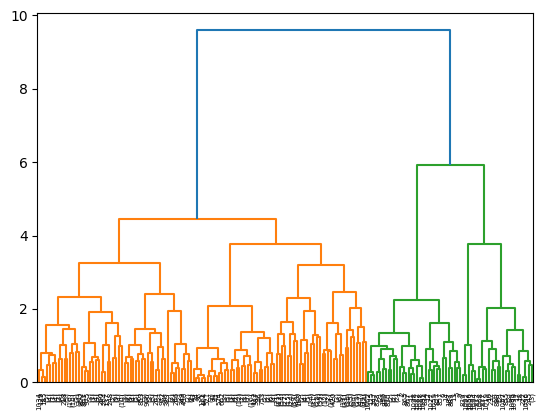

In [6]:
Z = linkage(dist_matrix_soap_isomers, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=7, 
)

In [7]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=5, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix_full)
print(np.unique(labels_hier, return_counts=True))
#df_isomers = df_isomers.with_columns(labels_hier=labels_hier)

(array([0, 1, 2, 3, 4]), array([3547,    4,   59,   13, 1377]))


In [ ]:
create_chemiscope_viewer(df, dist_matrix_full, labels_hier, 'MDS')

2026-05-12 14:43:51.876 | INFO     | src.helper_functions:create_chemiscope_viewer:1144 - Running MDS dimensionality reduction...
2026-05-12 14:43:51.877 | INFO     | src.helper_functions:create_chemiscope_viewer:1153 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


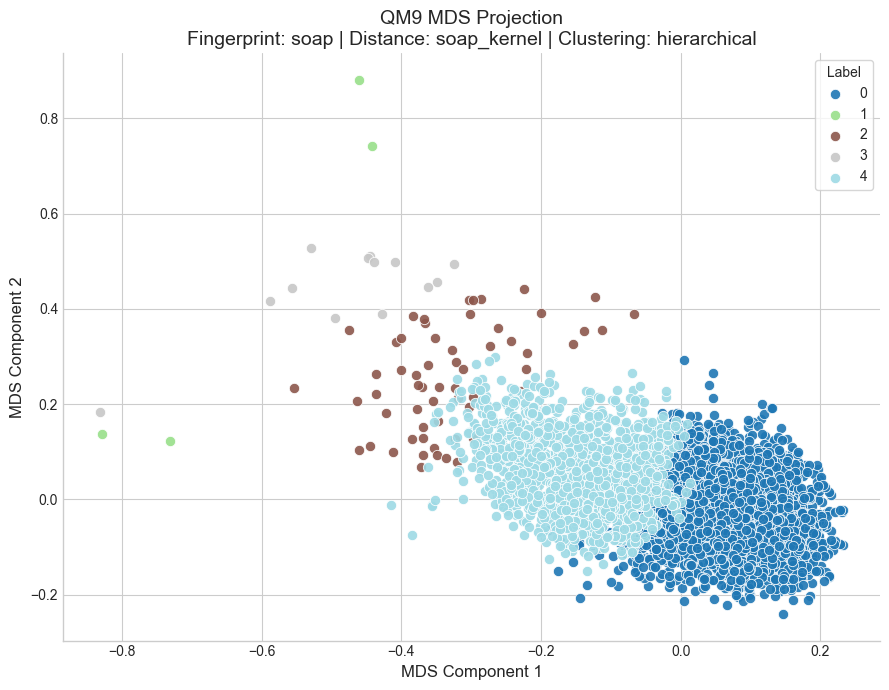

2026-05-11 20:17:40.160 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:609 - Saved MDS projection plot to figures/qm9/clustering/soap_kernel/soap/mds_hierarchical_projection.png


In [ ]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_full,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

# Riemann

In [ ]:
df['num_atoms'].min(), df['num_atoms'].max()

(3, 29)

In [6]:
riemann = Riemann()
dist_matrix_riemann = riemann.distance_matrix(df=df, descriptor='soap')
dist_matrix_riemann_isomers = riemann.distance_matrix(df=df_isomers, descriptor='soap')

2026-05-12 14:49:39.349 | INFO     | src.non_euclidean:distance_matrix:1107 - Computing Riemann distance matrix | Features: soap | Distance: affine-invariant
2026-05-12 14:49:39.351 | INFO     | src.non_euclidean:_feature_matrices_from_df:331 - Using column: soap_matrix from df
2026-05-12 14:49:40.497 | INFO     | src.non_euclidean:matrix_pca:1068 - Applying PCA to reduce feature dimension to 5...
2026-05-12 14:49:40.606 | INFO     | src.non_euclidean:matrix_pca:1083 - PCA explained variance ratio: 0.8470 (cumulative for 5 components)
2026-05-12 14:49:40.637 | INFO     | src.non_euclidean:distance_matrix:1118 - Computing affine-invariant distances...
2026-05-12 14:49:55.266 | INFO     | src.non_euclidean:distance_matrix:1107 - Computing Riemann distance matrix | Features: soap | Distance: affine-invariant
2026-05-12 14:49:55.267 | INFO     | src.non_euclidean:_feature_matrices_from_df:331 - Using column: soap_matrix from df
2026-05-12 14:49:55.458 | INFO     | src.non_euclidean:matrix_

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_50439/3592406822.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_riemann, method='complete')


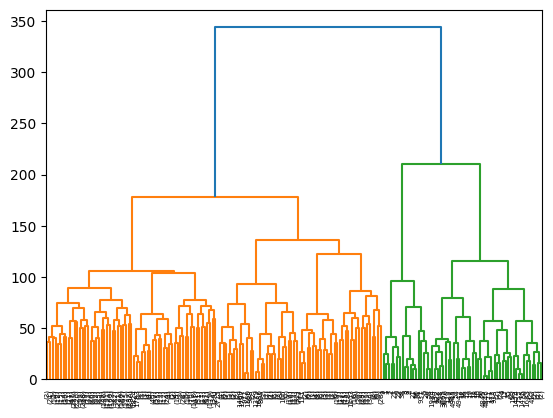

In [7]:
Z = linkage(dist_matrix_riemann, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=7, 
)

In [8]:
model_hier_riemann = AgglomerativeClustering(metric='precomputed', n_clusters=5, linkage='complete')
labels_hier_riemann = model_hier_riemann.fit_predict(dist_matrix_riemann)
print(np.unique(labels_hier_riemann, return_counts=True))
df = df.with_columns(labels_hier_riemann=labels_hier_riemann)

(array([0, 1, 2, 3, 4]), array([   5, 4534,   21,    2,  438]))


In [9]:
create_chemiscope_viewer(df, dist_matrix_riemann, labels_hier_riemann, 'MDS')

2026-05-12 14:50:26.838 | INFO     | src.helper_functions:create_chemiscope_viewer:1144 - Running MDS dimensionality reduction...
2026-05-12 14:50:26.839 | INFO     | src.helper_functions:create_chemiscope_viewer:1153 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-12 14:55:29.191 | INFO     | src.helper_functions:create_chemiscope_viewer:1221 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

In [ ]:
_=average_numeric_by_cluster(df, "labels_hier_riemann")

shape: (7, 72)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬─────────┬────────┬────────┬────────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


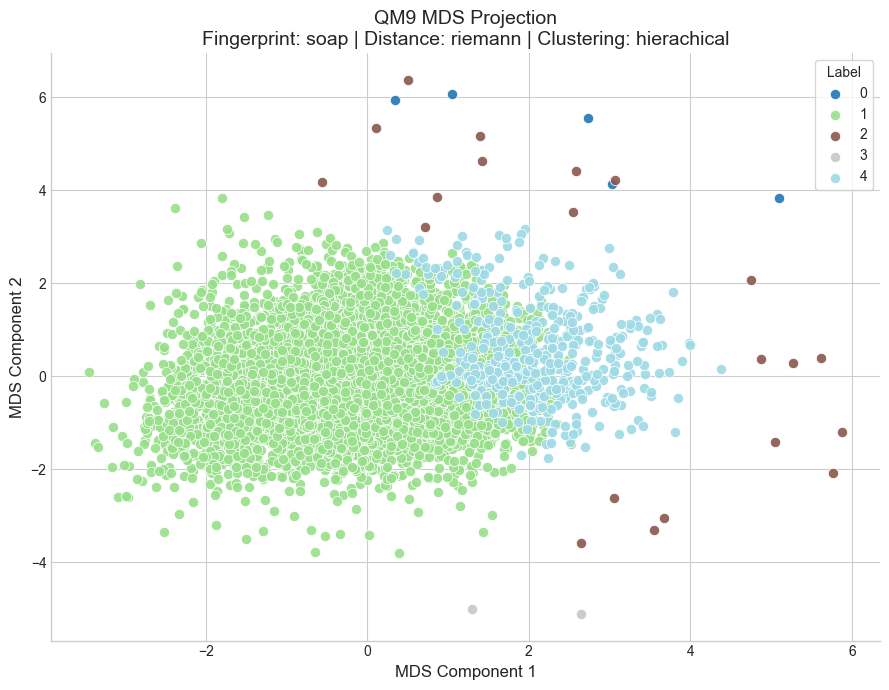

2026-05-12 15:00:42.283 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:609 - Saved MDS projection plot to figures/qm9/clustering/riemann/soap/mds_hierachical_projection.png


In [10]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_riemann,
    fingerprint="soap",
    distance_metric="riemann",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier_riemann,
    clustering_method="hierachical"
)

In [ ]:
spd_matrices = riemann._get_spd_matrices(df, descriptor='soap', pca_components=n_pca=)

# Grassmann

2026-05-11 20:18:09.406 | INFO     | src.non_euclidean:_feature_matrices_from_df:331 - Using column: soap_matrix from df


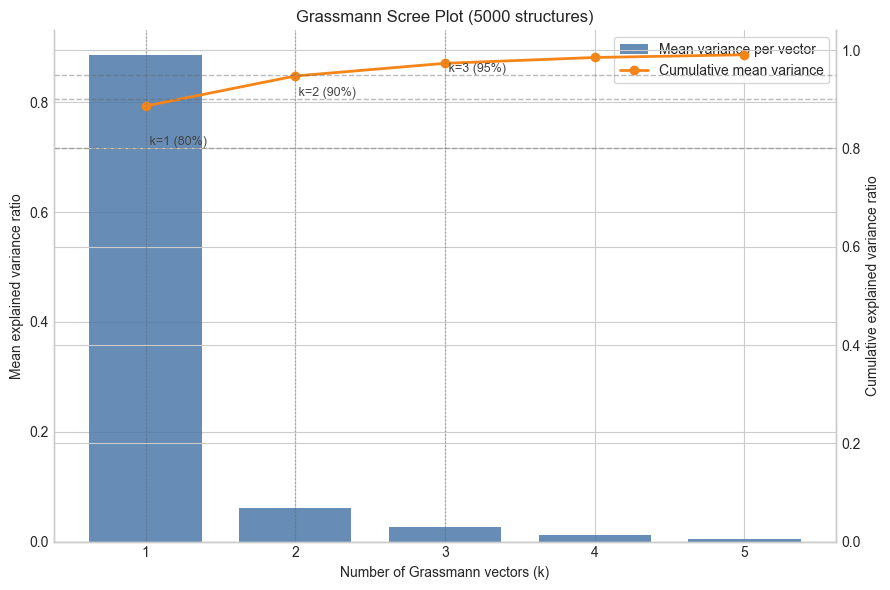

2026-05-11 20:18:11.052 | INFO     | src.non_euclidean:_feature_matrices_from_df:331 - Using column: soap_matrix from df


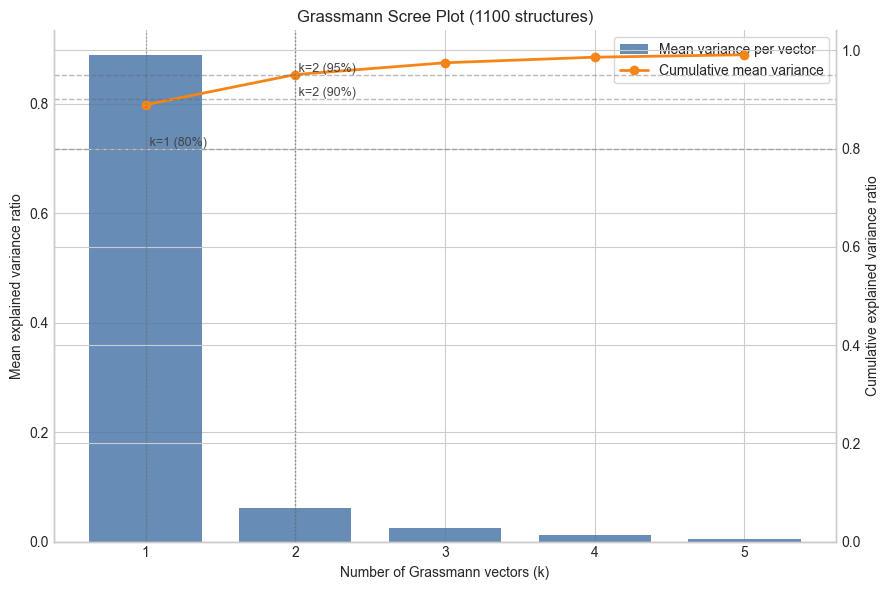

In [ ]:
grassmann = Grassmann()
# determine how many dimensions to keep
result=plot_grassmann_scree(df=df, descriptor='soap', k=5)
result=plot_grassmann_scree(df=df_isomers, descriptor='soap', k=5)

In [13]:
grassmann = Grassmann()
#dist_matrix_full_left = grassmann.distance_matrix(df=df, descriptor='soap', vector_side="left")
#dist_matrix_full_right = grassmann.distance_matrix(df=df, descriptor='soap', vector_side="right", k=2)
#dist_matrix_grass_left = grassmann.distance_matrix(df=df_isomers, descriptor='soap', vector_side="left", k=2)
dist_matrix_grass_right = grassmann.distance_matrix(df=df_isomers, descriptor='soap', vector_side="right", k=2)

2026-05-12 16:07:20.922 | INFO     | src.non_euclidean:_feature_matrices_from_df:331 - Using column: soap_matrix from df
2026-05-12 16:07:21.984 | INFO     | src.non_euclidean:distance_matrix:993 - Computing Grassmann distance matrix | Features: soap | Distance: geodesic | k: 2
Grassmann distances: 100%|██████████| 1100/1100 [00:06<00:00, 179.09row/s]


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_50439/2670499851.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_grass_right, method='average')


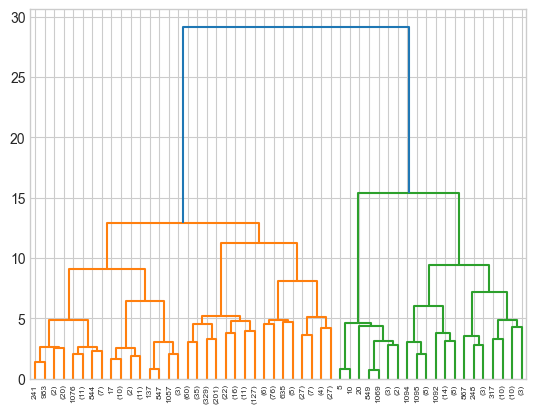

In [14]:
Z = linkage(dist_matrix_grass_right, method='average')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=5, 
)

In [15]:
model_hier_grass = AgglomerativeClustering(metric='precomputed', n_clusters=6, linkage='average')
labels_hier_grass = model_hier_grass.fit_predict(dist_matrix_grass_right)
print(np.unique(labels_hier_grass, return_counts=True))
df_isomers = df_isomers.with_columns(labels_hier_grass=labels_hier_grass)

(array([0, 1, 2, 3, 4, 5]), array([984,  51,  12,   3,  47,   3]))


In [19]:
create_chemiscope_viewer(df_isomers, dist_matrix_grass_right, labels_hier_grass, 'MDS')

2026-05-12 16:08:30.515 | INFO     | src.helper_functions:create_chemiscope_viewer:1144 - Running MDS dimensionality reduction...
2026-05-12 16:08:30.520 | INFO     | src.helper_functions:create_chemiscope_viewer:1153 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-12 16:08:44.868 | INFO     | src.helper_functions:create_chemiscope_viewer:1221 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

In [ ]:
_=average_numeric_by_cluster(df, "labels_hier_grass")

shape: (6, 71)
┌─────────────────┬───────┬─────────────────┬─────────────┬────────────┬────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬─────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


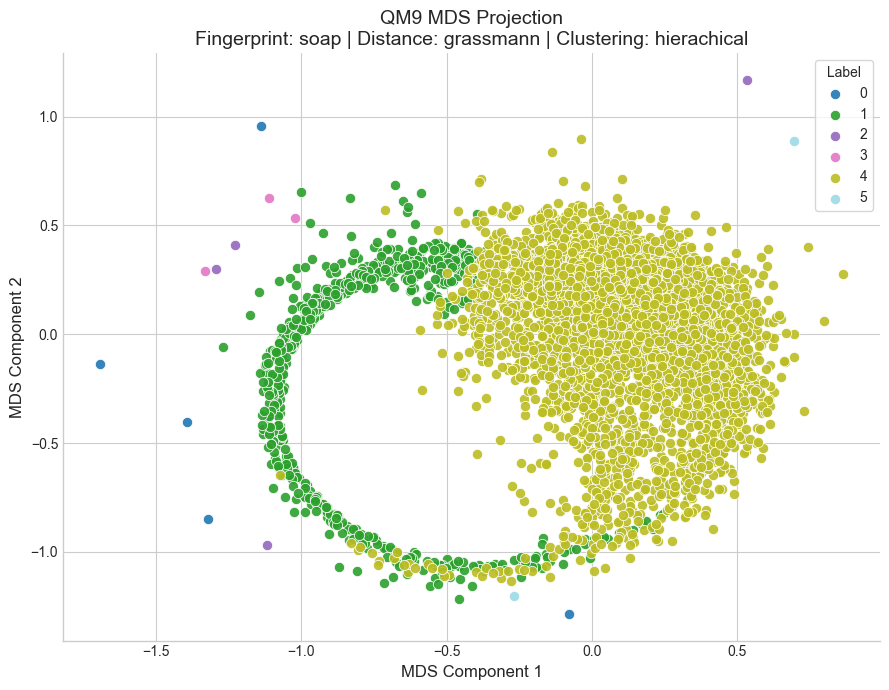

2026-05-11 20:30:31.275 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:609 - Saved MDS projection plot to figures/qm9/clustering/grassmann/soap/mds_hierachical_projection.png


In [ ]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_full_right,
    fingerprint="soap",
    distance_metric="grassmann",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier_grass,
    clustering_method="hierachical"
)

# Wasserstein

In [20]:
wasserstein = Wasserstein()
dist_matrix_wasser = wasserstein.distance_matrix(df=df, descriptor='soap')
dist_matrix_wasser_isomers = wasserstein.distance_matrix(df=df_isomers, descriptor='soap')

2026-05-12 17:35:02.545 | INFO     | src.non_euclidean:_feature_matrices_from_df:331 - Using column: soap_matrix from df
2026-05-12 17:35:05.669 | INFO     | src.non_euclidean:distance_matrix:750 - Computing Wasserstein distance matrix sequentially | Features: soap | Metric: sqeuclidean
Wasserstein distances: 100%|██████████| 5000/5000 [2:59:40<00:00,  2.16s/row]     
2026-05-12 20:34:46.531 | INFO     | src.non_euclidean:_feature_matrices_from_df:331 - Using column: soap_matrix from df
2026-05-12 20:34:47.054 | INFO     | src.non_euclidean:distance_matrix:750 - Computing Wasserstein distance matrix sequentially | Features: soap | Metric: sqeuclidean
Wasserstein distances: 100%|██████████| 1100/1100 [00:45<00:00, 24.26row/s] 


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_27452/4148681258.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_wasser_isomers, method='complete')


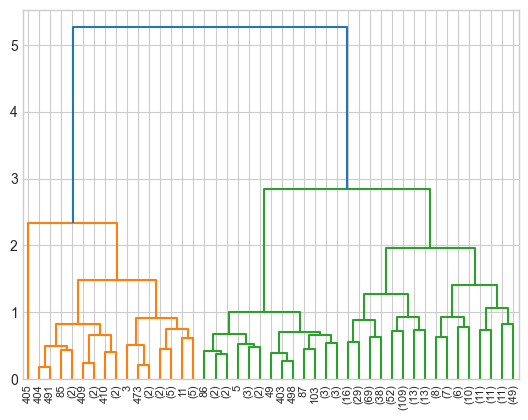

In [ ]:
Z = linkage(dist_matrix_wasser, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=5, 
)

In [21]:
model_hier_wasser = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier_wasser = model_hier_wasser.fit_predict(dist_matrix_wasser)
print(np.unique(labels_hier_wasser, return_counts=True))
df = df.with_columns(labels_hier_wasser=labels_hier_wasser)

(array([0, 1, 2, 3]), array([ 507,   13, 4446,   34]))


In [22]:
create_chemiscope_viewer(df, dist_matrix_wasser, labels_hier_wasser, 'MDS')

2026-05-12 20:40:29.293 | INFO     | src.helper_functions:create_chemiscope_viewer:1144 - Running MDS dimensionality reduction...
2026-05-12 20:40:29.304 | INFO     | src.helper_functions:create_chemiscope_viewer:1153 - Converting structures/molecules to ASE Atoms for Chemiscope...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-12 20:47:06.186 | INFO     | src.helper_functions:create_chemiscope_viewer:1221 - Assembling properties for Chemiscope...
2026-05-12 20:47:06.333 | INFO     | src.helper_functions:create_chemiscope_viewer:1316 - Generating Chemiscope widget...
2026-05-12 20:47:06.720 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1347 - Saved Chemiscope input to: qm9_MDS_clust

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

In [ ]:
average_numeric_by_cluster(df, "labels_hier_wasser")

shape: (4, 72)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬─────────┬────────┬────────┬────────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_hier_wasser,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier_grass,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,583,0.785491,0.0,121.123499,-0.144082,37.982847,0.862945,12.831972,8.687822,1.806175,0.09777,0.0,2.526587,17.557461,2.077014,2.027444,0.085443,0.203689,0.710869,0.948542,2.042882,6.281304,0.566038,1.185249,4.409949,6.320755,13.603774,1.265563,0.0,0.283019,0.015437,0.157804,0.173242,0.001715,0.056604,0.166381,0.58319,0.0,2.819185,72.934237,-6.580194,0.117779,6.698062,1159.480579,3.79215,-11107.201947,-11106.977972,-11106.952259,-11108.107072,30.483477,-73.059074,-73.49558,-73.910331,-68.045684,3.574153,1.437453,1.164617,1.317324,77.701544,9.777015,12.521441,13.603774,305,"""Acyclic""",12.521441,124,"""Acyclic""",12.521441,1,null,0.0
1,178,0.799515,0.0,117.353933,0.02809,48.095506,0.781216,12.85558,8.488764,0.865169,0.494382,0.022472,3.016854,14.94382,1.982559,1.870787,0.181106,0.505959,0.312935,1.033708,2.455056,5.033708,1.196629,2.466292,1.808989,6.797753,11.713483,1.255537,0.0,0.129213,0.140449,0.280899,0.146067,0.0,0.050562,0.101124,0.365169,0.0,2.907687,71.750562,-6.498797,-0.568412,5.930385,1264.524028,3.044193,-11098.242728,-11098.01833,-11097.992646,-11099.158664,29.25541,-65.145574,-65.487821,-65.839964,-60.863457,4.902458,1.311755,0.984108,1.365169,29.775281,46.629213,23.595506,11.713483,68,"""Acyclic""",23.595506,20,"""C1CCCC1""",29.775281,1,null,0.0
2,736,0.701492,0.0,124.830163,0.279891,29.362772,0.912963,12.830084,8.889946,1.691576,0.027174,0.0,1.96875,20.326087,2.062709,2.807065,0.033792,0.116211,0.849997,0.828804,1.695652,7.096467,0.235054,0.786685,5.899457,6.339674,14.13587,1.259589,0.0,0.44837,0.002717,0.052989,0.088315,0.0,0.027174,0.116848,0.581522,0.0,2.358221,78.804103,-6.539388,0.812781,7.352165,1226.464711,4.694099,-11061.919772,-11061.674896,-11061.64919,-11062.840585,33.888299,-83.178586,-83.708937,-84.200233,-77.3037,2.883195,1.35847,1.100197,1.133152,88.043478,2.717391,9.23913,14.13587,346,"""Acyclic""",9.23913,141,"""C1CC1""",12.771739,1,null,0.0
3,3,0.763468,0.0,93.666667,0.0,30.333333,1.033988,12.471591,7.0,0.0,0.0,0.0,1.666667,10.666667,1.809764,0.333333,0.538095,0.264286,0.197619,0.0,1.666667,2.333333,3.0,1.333333,1.0,6.333333,8.333333,1.247606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.0,0.0,5.367267,67.139998,-7.215552,-2.556963,4.659496,1212.334391,1.951882,-8811.836263,-8811.622884,-8811.597331,-8812.776042,24.488333,-50.735743,-50.933533,-51.181938,-47.822701,18.560067,1.30548,1.206843,4.0,0.0,0.0,100.0,8.333333,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


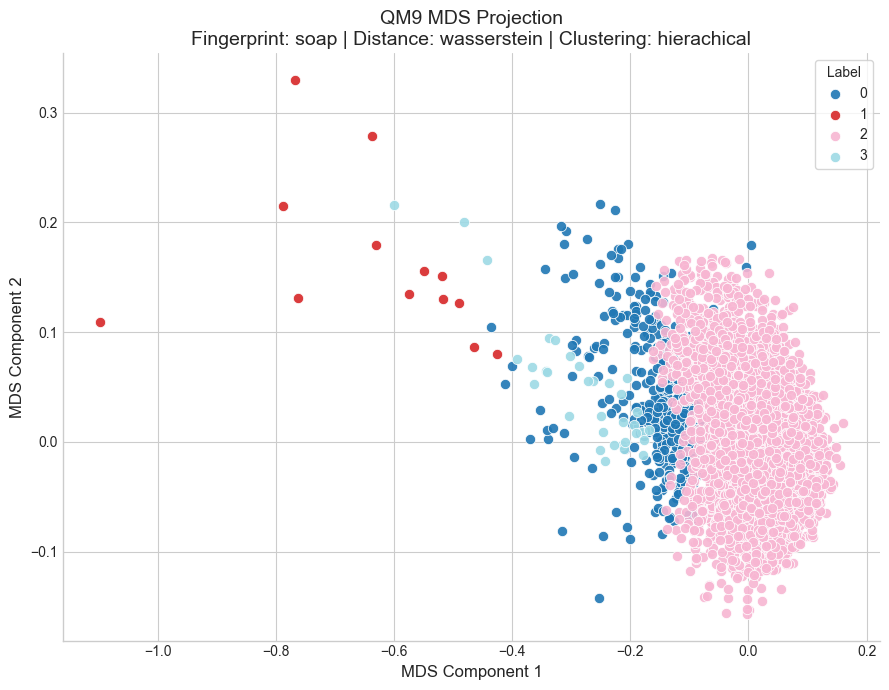

2026-05-12 20:53:12.784 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:609 - Saved MDS projection plot to figures/qm9/clustering/wasserstein/soap/mds_hierachical_projection.png


In [23]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_wasser,
    fingerprint="soap",
    distance_metric="wasserstein",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier_wasser,
    clustering_method="hierachical"
)